In [1]:
# Enable Logging

import logging
import pandas as pd
from pathlib import Path

# --------------------------------------------------
# Create logs folder if it does not exist
# --------------------------------------------------
LOG_DIR = Path("../logs")
LOG_DIR.mkdir(parents=True, exist_ok=True)

LOG_FILE = LOG_DIR / "store_sales_machine_learning.log"

# --------------------------------------------------
# Create logger
# --------------------------------------------------
logger = logging.getLogger("StoreSales_machine_learning")
logger.setLevel(logging.DEBUG)

# Prevent duplicate handlers if this cell is run again
if logger.hasHandlers():
    logger.handlers.clear()

# --------------------------------------------------
# Console handler
# --------------------------------------------------
console_handler = logging.StreamHandler()
console_handler.setLevel(logging.DEBUG)

# --------------------------------------------------
# File handler
# --------------------------------------------------
file_handler = logging.FileHandler(
    LOG_FILE,
    mode="a",
    encoding="utf-8"
)
file_handler.setLevel(logging.DEBUG)

# --------------------------------------------------
# Formatter
# --------------------------------------------------
formatter = logging.Formatter(
    "%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)

console_handler.setFormatter(formatter)
file_handler.setFormatter(formatter)

# --------------------------------------------------
# Add handlers
# --------------------------------------------------
logger.addHandler(console_handler)
logger.addHandler(file_handler)

# --------------------------------------------------
# First log message
# --------------------------------------------------
logger.info("Store Sales Machine Learning Test Train Model notebook started.")

print(f"Logging enabled: {LOG_FILE.resolve()}")

2026-09-14 19:36:19,985 - StoreSales_machine_learning - INFO - Store Sales Machine Learning Test Train Model notebook started.


Logging enabled: C:\Users\AMOGH\Desktop\Nexthikes_Projects\Project6_Sales Forecasting_DL\rossmann-store-sales\Store_Sales_Project\logs\store_sales_machine_learning.log


In [2]:
# Load Data
logger.info("Starting dataset loading process - feature_engineering_store_train and store_test.")
import pandas as pd
import numpy as np

store_train = pd.read_csv(
    "../data/feature_engineered_store_train.csv"
)

store_test = pd.read_csv(
    "../data/feature_engineered_store_test.csv"
)
logger.info("feature_engineered_store_train.csv loaded successfully.")
logger.info("feature_engineered_store_test.csv loaded successfully.")

# Log dataset dimensions
logger.debug(f"Store Train dataset shape: {store_train.shape}")
logger.debug(f"Store Test dataset shape: {store_test.shape}")

print("Store Train Shape:", store_train.shape)
print("Store Test Shape:", store_test.shape)

display(store_train.head())
display(store_test.head())

2026-09-14 19:39:55,210 - StoreSales_machine_learning - INFO - Starting dataset loading process - feature_engineering_store_train and store_test.
C:\Users\AMOGH\AppData\Local\Temp\ipykernel_4760\1473629308.py:6: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  store_train = pd.read_csv(
C:\Users\AMOGH\AppData\Local\Temp\ipykernel_4760\1473629308.py:10: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  store_test = pd.read_csv(
2026-09-14 19:39:58,501 - StoreSales_machine_learning - INFO - feature_engineered_store_train.csv loaded successfully.
2026-09-14 19:39:58,502 - StoreSales_machine_learning - INFO - feature_engineered_store_test.csv loaded successfully.
2026-09-14 19:39:58,505 - StoreSales_machine_learning - DEBUG - Store Train dataset shape: (1017209, 28)
2026-09-14 19:39:58,506 - StoreSales_machine_learning - DEBUG - Store Test dataset shape: (410

Store Train Shape: (1017209, 28)
Store Test Shape: (41088, 27)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,...,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,DayOfYear,Quarter,IsWeekend,CompetitionOpenMonths,Promo2OpenWeeks,IsPromoMonth
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,...,0,0.0,0.0,NaN,212,3,0,82.0,0.0,0
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,...,1,13.0,2010.0,"Jan,Apr,Jul,Oct",212,3,0,92.0,278.0,1
2,3,5,2015-07-31,8314,821,1,1,0,1,2015,...,1,14.0,2011.0,"Jan,Apr,Jul,Oct",212,3,0,103.0,225.0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1,2015,...,0,0.0,0.0,NaN,212,3,0,70.0,0.0,0
4,5,5,2015-07-31,4822,559,1,1,0,1,2015,...,0,0.0,0.0,NaN,212,3,0,3.0,0.0,0


,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,...,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,DayOfYear,Quarter,IsWeekend,CompetitionOpenMonths,Promo2OpenWeeks,IsPromoMonth
0,1.0,1.0,4.0,2015-09-17,1.0,1.0,0,0.0,2015,9,...,0,0.0,0.0,NaN,260,3,0,84.0,0.0,0
1,2.0,3.0,4.0,2015-09-17,1.0,1.0,0,0.0,2015,9,...,1,14.0,2011.0,"Jan,Apr,Jul,Oct",260,3,0,105.0,232.0,0
2,3.0,7.0,4.0,2015-09-17,1.0,1.0,0,0.0,2015,9,...,0,0.0,0.0,NaN,260,3,0,29.0,0.0,0
3,4.0,8.0,4.0,2015-09-17,1.0,1.0,0,0.0,2015,9,...,0,0.0,0.0,NaN,260,3,0,11.0,0.0,0
4,5.0,9.0,4.0,2015-09-17,1.0,1.0,0,0.0,2015,9,...,0,0.0,0.0,NaN,260,3,0,181.0,0.0,0


In [3]:
# Verify the data before modeling
print("Missing values in Train:")
print(store_train.isnull().sum().sum())

print("\nMissing values in Test:")
print(store_test.isnull().sum().sum())

print("\nDuplicate rows in Train:")
print(store_train.duplicated().sum())

print("\nTrain Data Types:")
print(store_train.dtypes)

print("\nCategorical Columns:")
print(
    store_train
    .select_dtypes(include=["object"])
    .columns
    .tolist()
)

Missing values in Train:
508031

Missing values in Test:
17232

Duplicate rows in Train:
0

Train Data Types:
Store                          int64
DayOfWeek                      int64
Date                             str
Sales                          int64
Customers                      int64
Open                           int64
Promo                          int64
StateHoliday                  object
SchoolHoliday                  int64
Year                           int64
Month                          int64
Day                            int64
WeekOfYear                     int64
StoreType                        str
Assortment                       str
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                    str
DayOfYear                      int64
Quarter                        int64
Is

C:\Users\AMOGH\AppData\Local\Temp\ipykernel_4760\1425399538.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  .select_dtypes(include=["object"])


In [ ]:
train_missing = store_train.isnull().sum()
train_missing = train_missing[train_missing > 0].sort_values(ascending=False)

test_missing = store_test.isnull().sum()
test_missing = test_missing[test_missing > 0].sort_values(ascending=False)

print("TRAIN:")
print(train_missing)

print("\nTEST:")
print(test_missing)

TRAIN:
PromoInterval    508031
dtype: int64

TEST:
PromoInterval    17232
dtype: int64


In [ ]:
print("\nRows in Train:", len(store_train))
print("Rows in Test:", len(store_test))

print("\nTrain columns with missing values:",
      train_missing.index.tolist())

print("\nTest columns with missing values:",
      test_missing.index.tolist())


Rows in Train: 1017209
Rows in Test: 41088

Train columns with missing values: ['PromoInterval']

Test columns with missing values: ['PromoInterval']


In [4]:
# Fill missing PromoInterval values
logger.info("Filling PromoInterval missing value to NoPromo.")
store_train["PromoInterval"] = (
    store_train["PromoInterval"].fillna("NoPromo")
)

store_test["PromoInterval"] = (
    store_test["PromoInterval"].fillna("NoPromo")
)

2026-09-14 19:42:21,104 - StoreSales_machine_learning - INFO - Filling PromoInterval missing value to NoPromo.


In [ ]:
print("Missing values in Train:",
      store_train.isnull().sum().sum())

print("Missing values in Test:",
      store_test.isnull().sum().sum())

print(store_train["PromoInterval"].value_counts(dropna=False))

print("\nTest:")
print(store_test["PromoInterval"].value_counts(dropna=False))

Missing values in Train: 0
Missing values in Test: 0
PromoInterval
NoPromo             508031
Jan,Apr,Jul,Oct     293122
Feb,May,Aug,Nov     118596
Mar,Jun,Sept,Dec     97460
Name: count, dtype: int64

Test:
PromoInterval
NoPromo             17232
Jan,Apr,Jul,Oct     13776
Feb,May,Aug,Nov      5712
Mar,Jun,Sept,Dec     4368
Name: count, dtype: int64


In [7]:
# Find categorical columns in training data
categorical_columns = store_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
['Date', 'StateHoliday', 'StoreType', 'Assortment', 'PromoInterval']


C:\Users\AMOGH\AppData\Local\Temp\ipykernel_4760\842258098.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = store_train.select_dtypes(


In [8]:
# Useful check before encoding:

for col in categorical_columns:
    print(f"\n{col}")
    print(store_train[col].value_counts())


Date
Date
2015-07-31    1115
2015-07-30    1115
2015-07-29    1115
2015-07-28    1115
2015-07-27    1115
              ... 
2014-07-05     935
2014-07-04     935
2014-07-03     935
2014-07-02     935
2014-07-01     935
Name: count, Length: 942, dtype: int64

StateHoliday
StateHoliday
0    592943
0    393216
a     20260
b      6690
c      4100
Name: count, dtype: int64

StoreType
StoreType
a    551627
d    312912
c    136840
b     15830
Name: count, dtype: int64

Assortment
Assortment
a    537445
c    471470
b      8294
Name: count, dtype: int64

PromoInterval
PromoInterval
NoPromo             508031
Jan,Apr,Jul,Oct     293122
Feb,May,Aug,Nov     118596
Mar,Jun,Sept,Dec     97460
Name: count, dtype: int64


In [9]:
# Step 1 — Standardize StateHoliday, Run this for both datasets:
# Convert StateHoliday consistently to string
store_train["StateHoliday"] = (
    store_train["StateHoliday"]
    .astype(str)
    .str.strip()
    .replace({
        "0.0": "0",
        "nan": "0"
    })
)

store_test["StateHoliday"] = (
    store_test["StateHoliday"]
    .astype(str)
    .str.strip()
    .replace({
        "0.0": "0",
        "nan": "0"
    })
)

print("Train:")
print(store_train["StateHoliday"].value_counts())

print("\nTest:")
print(store_test["StateHoliday"].value_counts())

Train:
StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64

Test:
StateHoliday
0    40908
a      180
Name: count, dtype: int64


In [10]:
# Date is already encoded in previous file , So the original date column can now be removed:
store_train.drop(columns=["Date"], inplace=True)
store_test.drop(columns=["Date"], inplace=True)

In [11]:
# Then check
categorical_columns = store_train.select_dtypes(
    include=["object"]
).columns.tolist()

print(categorical_columns)

['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval']


C:\Users\AMOGH\AppData\Local\Temp\ipykernel_4760\3427453485.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = store_train.select_dtypes(


In [12]:
# Encoding :
# Step-1 One-hot encode train and test
# Categorical columns
logger.info("Starting One-hot encode on train and test...")
categorical_columns = [
    "StateHoliday",
    "StoreType",
    "Assortment",
    "PromoInterval"
]
# One-Hot Encoding
store_train_encoded = pd.get_dummies(
    store_train,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)
store_test_encoded = pd.get_dummies(
    store_test,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)
# Log dataset dimensions
logger.debug(f"Store Train encoded dataset shape: {store_train_encoded.shape}")
logger.debug(f"Store Test encoded dataset shape: {store_test_encoded.shape}")

print("Train shape after encoding:",
      store_train_encoded.shape)
print("Test shape after encoding:",
      store_test_encoded.shape)

2026-09-14 19:47:52,635 - StoreSales_machine_learning - INFO - Starting One-hot encode on train and test...
2026-09-14 19:47:53,077 - StoreSales_machine_learning - DEBUG - Store Train encoded dataset shape: (1017209, 34)
2026-09-14 19:47:53,093 - StoreSales_machine_learning - DEBUG - Store Test encoded dataset shape: (41088, 31)


Train shape after encoding: (1017209, 34)
Test shape after encoding: (41088, 31)


In [13]:
# Step 2 — Check that no object columns remain
print("Object columns in Train:")
print(
    store_train_encoded
    .select_dtypes(include=["object"])
    .columns.tolist()
)

print("\nObject columns in Test:")
print(
    store_test_encoded
    .select_dtypes(include=["object"])
    .columns.tolist()
)

Object columns in Train:
[]

Object columns in Test:
[]


In [14]:
# Step 3 — Check the newly encoded columns
encoded_columns = [
    col for col in store_train_encoded.columns
    if any(cat in col for cat in categorical_columns)
]

print("Encoded Columns:")
print(encoded_columns)
logger.info("Finished One-hot encode on train and test.")

2026-09-14 19:48:10,796 - StoreSales_machine_learning - INFO - Finished One-hot encode on train and test.


Encoded Columns:
['StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_b', 'Assortment_c', 'PromoInterval_Jan,Apr,Jul,Oct', 'PromoInterval_Mar,Jun,Sept,Dec', 'PromoInterval_NoPromo']


In [18]:
# Feature and target preparation.
# Separate target (Sales) from features, Sales is what we want to predict.
# Also, remove Customers because it exists in the training data but not in the test data, so it cannot be used for final test predictions.
logger.info("Starting Feature and target preparation....")
y = store_train_encoded["Sales"]
# Training features
X = store_train_encoded.drop(
    columns=["Sales", "Customers"]
)
# Log dataset dimensions
logger.debug(f"Store Train Encoded X without 'Sales' and 'Customers' dataset shape: {X.shape}")
logger.debug(f"Store Train Target y target 'Sales' dataset shape: {y.shape}")
print("X shape:", X.shape)
print("y shape:", y.shape)

2026-09-14 19:56:34,631 - StoreSales_machine_learning - INFO - Starting Feature and target preparation....
2026-09-14 19:56:34,637 - StoreSales_machine_learning - DEBUG - Store Train Encoded X without 'Sales' and 'Customers' dataset shape: (1017209, 32)
2026-09-14 19:56:34,638 - StoreSales_machine_learning - DEBUG - Store Train Target y target 'Sales' dataset shape: (1017209,)


X shape: (1017209, 32)
y shape: (1017209,)


In [ ]:
# Prepare the test features
# The test dataset contains Id. We need to preserve it for the final prediction file, but it should not be used for training.
# Save Id for final submission/prediction file

test_id = store_test_encoded["Id"].copy()
# Remove Id from model features
X_test = store_test_encoded.drop(
    columns=["Id"]
)
print("X_test shape:", X_test.shape)

X_test shape: (41088, 30)


In [24]:
# Align train and test columns
# This is important because one-hot encoding was performed separately. A category might occur in train but not test, or vice versa.

X, X_test = X.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

# Log dataset dimensions
logger.debug(f"X shape after alignment: {X.shape}")
logger.debug(f"X_test shape after alignment: {X_test.shape}")

print("X shape after alignment:", X.shape)
print("X_test shape after alignment:", X_test.shape)

print(
    "Train and Test columns identical:",
    list(X.columns) == list(X_test.columns)
)

2026-09-14 20:00:56,402 - StoreSales_machine_learning - DEBUG - X shape after alignment: (1017209, 32)
2026-09-14 20:00:56,402 - StoreSales_machine_learning - DEBUG - X_test shape after alignment: (41088, 32)


X shape after alignment: (1017209, 32)
X_test shape after alignment: (41088, 32)
Train and Test columns identical: True


In [ ]:
# 4. Final sanity check before splitting
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

print("Object columns in X:",
      X.select_dtypes(include=["object"]).columns.tolist())

print("Object columns in X_test:",
      X_test.select_dtypes(include=["object"]).columns.tolist())

Missing values in X: 0
Missing values in X_test: 0
Object columns in X: []
Object columns in X_test: []


In [25]:
# Train/validation split, model building and then model comparison

logger.info("Starting Train/validation split, model building and comparison....")
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

2026-09-14 20:02:23,215 - StoreSales_machine_learning - INFO - Starting Train/validation split, model building and comparison....


X_train: (813767, 32)
X_valid: (203442, 32)
y_train: (813767,)
y_valid: (203442,)


In [26]:
# Model Building
# Starting with Random Forest using controlled parameters
logger.info("Starting with Random Forest using controlled parameters....")
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
logger.info("Random Forest training completed.")
print("Random Forest training completed.")

2026-09-14 20:03:49,538 - StoreSales_machine_learning - INFO - Starting with Random Forest using controlled parameters....


2026-09-14 20:09:28,491 - StoreSales_machine_learning - INFO - Random Forest training completed.


Random Forest training completed.


In [27]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np
y_pred_rf = rf_model.predict(X_valid)
rf_r2 = r2_score(y_valid, y_pred_rf)
rf_mae = mean_absolute_error(y_valid, y_pred_rf)
rf_rmse = np.sqrt(
    mean_squared_error(y_valid, y_pred_rf)
)

logger.info("Random Forest Results =")
logger.info("---------------------")
logger.debug(f"R² Score : {rf_r2}")
logger.debug(f"MAE      : {rf_mae}")
logger.debug(f"RMSE     : {rf_rmse}")

print("Random Forest Results")
print("---------------------")
print("R² Score :", rf_r2)
print("MAE      :", rf_mae)
print("RMSE     :", rf_rmse)

2026-09-14 20:12:20,422 - StoreSales_machine_learning - INFO - Random Forest Results =
2026-09-14 20:12:20,422 - StoreSales_machine_learning - INFO - ---------------------
2026-09-14 20:12:20,422 - StoreSales_machine_learning - DEBUG - R² Score : 0.8369611084701227
2026-09-14 20:12:20,436 - StoreSales_machine_learning - DEBUG - MAE      : 1016.8452385672946
2026-09-14 20:12:20,441 - StoreSales_machine_learning - DEBUG - RMSE     : 1552.7874725570423


Random Forest Results
---------------------
R² Score : 0.8369611084701227
MAE      : 1016.8452385672946
RMSE     : 1552.7874725570423


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np
import time
logger.info("Starting Model Comparison....")
models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )
}
results = []
for name, model in models.items():
    print(f"\nTraining {name}...")
    start = time.time()
    model.fit(X_train, y_train)
    predictions = model.predict(X_valid)
    r2 = r2_score(y_valid, predictions)
    mae = mean_absolute_error(y_valid, predictions)
    rmse = np.sqrt(
        mean_squared_error(y_valid, predictions)
    )
    elapsed = time.time() - start
    results.append({
        "Model": name,
        "R2 Score": r2,
        "MAE": mae,
        "RMSE": rmse,
        "Training Time (sec)": elapsed
    })
    logger.debug(f"{name} completed.")
    print(f"{name} completed.")


results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)
logger.debug(
    "Model comparison results:\n%s",
    results_df.to_string(index=False)
)
display(results_df)
logger.info(f"Model Comparison Finish ! ")

2026-09-14 20:21:31,417 - StoreSales_machine_learning - INFO - Starting Model Comparison....



Training Linear Regression...


2026-09-14 20:21:34,460 - StoreSales_machine_learning - DEBUG - Linear Regression completed.


Linear Regression completed.

Training Ridge Regression...


2026-09-14 20:21:35,278 - StoreSales_machine_learning - DEBUG - Ridge Regression completed.


...

2026-09-14 20:28:09,710 - StoreSales_machine_learning - DEBUG - Random Forest completed.


Random Forest completed.

Training Extra Trees...


2026-09-14 20:32:52,419 - StoreSales_machine_learning - DEBUG - Extra Trees completed.


Extra Trees completed.


NameError: name 'result_df' is not defined

In [33]:
# Identify and save the best model
best_model_name = results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)
logger.debug(f"Best Model: {best_model_name}")
best_model = models[best_model_name]

2026-09-14 20:40:50,345 - StoreSales_machine_learning - DEBUG - Best Model: Random Forest


Best Model: Random Forest


In [34]:
# Feature Importance
# This is important for the project report because it tells us which factors have the strongest influence on sales predictions.
logger.info("Starting Feature Importance....")
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)
print("Top 15 Important Features:")
display(feature_importance_df.head(15))
logger.info("Finish Feature Importance !")


2026-09-14 20:42:02,728 - StoreSales_machine_learning - INFO - Starting Feature Importance....


Top 15 Important Features:


,Feature,Importance
0,Open,0.556913
1,Promo,0.088971
2,CompetitionDistance,0.076349
3,Store,0.053487
4,CompetitionOpenSinceYear,0.029876
5,DayOfWeek,0.028450
6,CompetitionOpenSinceMonth,0.025341
7,Promo2SinceYear,0.020956
8,DayOfYear,0.020091
9,StoreType_b,0.017441


2026-09-14 20:42:02,985 - StoreSales_machine_learning - INFO - Finish Feature Importance !


In [ ]:
# Insights : Your Random Forest is relying heavily on Open, with importance 0.5569 (~55.7%).
# That makes sense: whether a store is open is the strongest immediate determinant of whether it can generate sales.
# Promo (8.9%) is the second-most important feature, showing that promotional activity has a substantial relationship with predicted sales.
# CompetitionDistance contributes about 7.6%, suggesting nearby competition is also relevant.
# The model additionally uses store identity, competition history, day of the week, Promo2 history, store type, assortment, and calendar-related features.

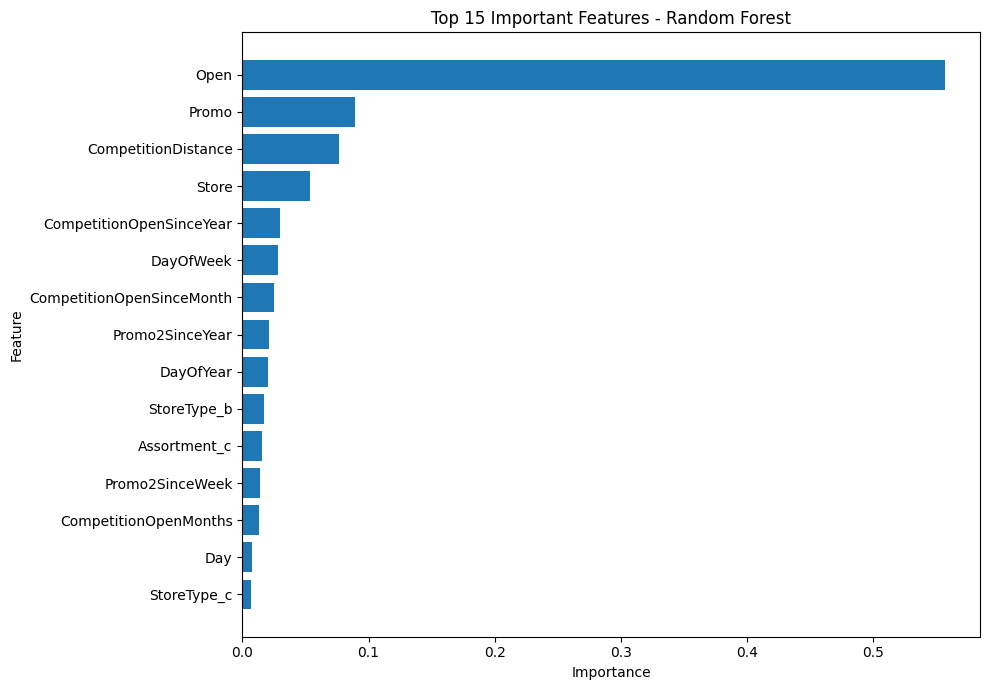

In [ ]:
# Create the graph
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(15)
plt.figure(figsize=(10, 7))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Important Features - Random Forest")
plt.tight_layout()
plt.show()

In [36]:
# Actual vs Predicted Sales
# Predictions on validation data
y_pred_best = best_model.predict(X_valid)

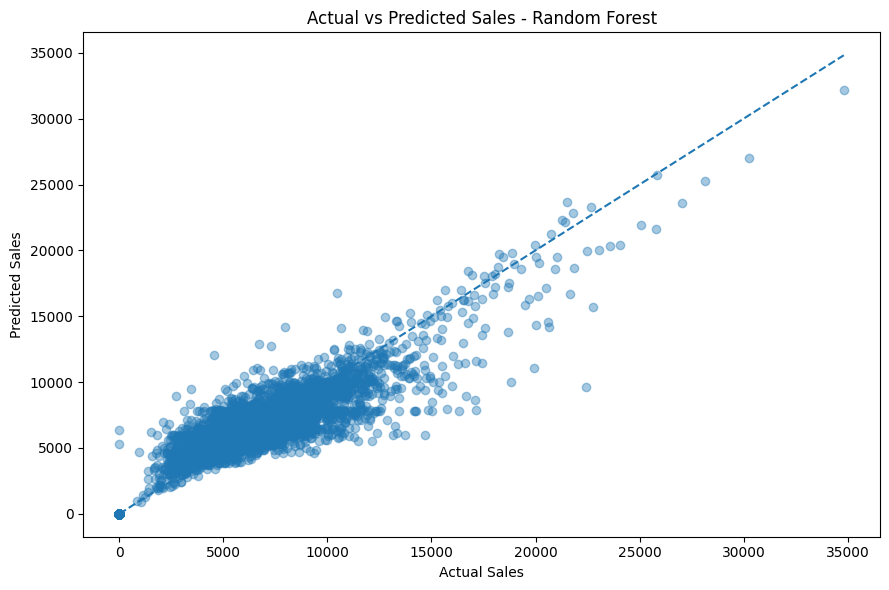

In [ ]:
# Plot actual vs predicted values. Since the validation set is large, using a sample so the graph stays readable.
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
sample_size = min(5000, len(y_valid))
sample_idx = np.random.choice(
    len(y_valid),
    size=sample_size,
    replace=False
)
actual_sample = y_valid.iloc[sample_idx]
predicted_sample = y_pred_best[sample_idx]
plt.figure(figsize=(9, 6))
plt.scatter(
    actual_sample,
    predicted_sample,
    alpha=0.4
)
min_value = min(actual_sample.min(), predicted_sample.min())
max_value = max(actual_sample.max(), predicted_sample.max())
plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales - Random Forest")
plt.tight_layout()
plt.show()

In [ ]:
# Analysis : Points close to the diagonal line mean the prediction is close to the actual sales.

In [37]:
# Residual analysis
# Residual = Actual Sales − Predicted Sales.
logger.info("Perfoming Residual Analaysis....")
residuals = y_valid.to_numpy() - y_pred_best
print("Mean Residual:", residuals.mean())
print("Minimum Residual:", residuals.min())
print("Maximum Residual:", residuals.max())
logger.info("Finish Residual Analaysis !")

2026-09-14 20:44:01,402 - StoreSales_machine_learning - INFO - Perfoming Residual Analaysis....
2026-09-14 20:44:01,418 - StoreSales_machine_learning - INFO - Finish Residual Analaysis !


Mean Residual: -1.8764135694666015
Minimum Residual: -10769.23952996902
Maximum Residual: 22086.514859795992


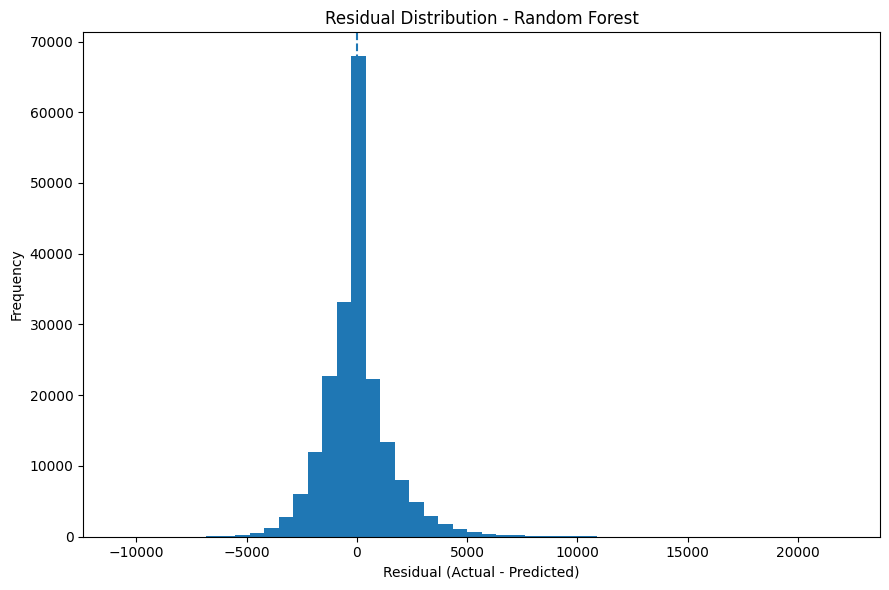

In [ ]:
# Visualizing the residual distribution: Ideally, most errors should be concentrated around 0.
plt.figure(figsize=(9, 6))
plt.hist(
    residuals,
    bins=50
)
plt.axvline(
    x=0,
    linestyle="--"
)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Residual Distribution - Random Forest")
plt.tight_layout()
plt.show()

In [40]:
# Make final predictions on test data
final_predictions = best_model.predict(X_test)
print("Number of predictions:", len(final_predictions))
print("\nFirst 10 predictions:")
print(final_predictions[:10])

Number of predictions: 41088

First 10 predictions:
[6304.11047095 7900.17106313 7784.78165207 6436.88001207 6989.95444818
 6336.34089479 7553.67780214 7675.02585014 6665.15334995 6864.97838822]


In [41]:
# Because sales cannot realistically be negative, protect against any negative predictions:
final_predictions = np.maximum(
    final_predictions,
    0
)
print("Minimum predicted sales:",
      final_predictions.min())

Minimum predicted sales: 0.0


In [42]:
# Create final prediction file
# Earlier we saved the test Id as test_id. Now combine it with predictions:
final_submission = pd.DataFrame({
    "Id": test_id,
    "Sales": final_predictions
})
print(final_submission.shape)
display(final_submission.head(10))

(41088, 2)


,Id,Sales
0,1.0,6304.110471
1,2.0,7900.171063
2,3.0,7784.781652
3,4.0,6436.880012
4,5.0,6989.954448
5,6.0,6336.340895
6,7.0,7553.677802
7,8.0,7675.025850
8,9.0,6665.153350
9,10.0,6864.978388


In [44]:
# Load into CSV : Here ML pipeline is essentially complete
logger.info("Saving final submission to final_sales_predictions.csv....")
final_submission.to_csv(
    "../data/final_sales_predictions.csv",
    index=False
)
print("Final prediction file saved successfully.")

2026-09-14 20:46:44,861 - StoreSales_machine_learning - INFO - Saving final submission to final_sales_predictions.csv....


Final prediction file saved successfully.


In [45]:
# Final verification:
print("Final Submission Shape:", final_submission.shape)
print(
    "Missing Predictions:",
    final_submission["Sales"].isnull().sum()
)
print(
    "Negative Predictions:",
    (final_submission["Sales"] < 0).sum()
)
print("\nPrediction Summary:")
print(final_submission["Sales"].describe())
display(final_submission.head(10))

Final Submission Shape: (41088, 2)
Missing Predictions: 0
Negative Predictions: 0

Prediction Summary:
count    41088.000000
mean      5880.171824
std       3205.141514
min          0.000000
25%       4774.943348
50%       6128.870479
75%       7591.036586
max      31718.838587
Name: Sales, dtype: float64


,Id,Sales
0,1.0,6304.110471
1,2.0,7900.171063
2,3.0,7784.781652
3,4.0,6436.880012
4,5.0,6989.954448
5,6.0,6336.340895
6,7.0,7553.677802
7,8.0,7675.025850
8,9.0,6665.153350
9,10.0,6864.978388
